In [50]:
!pip install kagglehub 

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
data = pd.read_csv(os.path.join(path, csv_file))


In [56]:
print(df.columns)
columns_to_show = ['AvgSessionDurationMinutes', 'SessionsPerWeek', 'PlayerLevel', 'PlayTimeHours', 'InGamePurchases', 'AchievementsUnlocked']
summary_table = df[columns_to_show].describe().T.round(0)
summary_table = summary_table.astype(int)
summary_table


Index(['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases',
       'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
       'AchievementsUnlocked', 'Gender_Male', 'Location_Europe',
       'Location_Other', 'Location_USA', 'GameGenre_RPG',
       'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy',
       'GameDifficulty_Hard', 'GameDifficulty_Medium', 'EngagementLevel_Low',
       'EngagementLevel_Medium'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
AvgSessionDurationMinutes,40034,95,49,10,52,95,137,179
SessionsPerWeek,40034,9,6,0,4,9,14,19
PlayerLevel,40034,50,29,1,25,49,74,99
PlayTimeHours,40034,12,7,0,6,12,18,24
InGamePurchases,40034,0,0,0,0,0,0,1
AchievementsUnlocked,40034,25,14,0,12,25,37,49


当前所有的列名有： ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'Gender_Male', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy', 'GameDifficulty_Hard', 'GameDifficulty_Medium', 'EngagementLevel_Low', 'EngagementLevel_Medium']
错误：找不到 EngagementLevel 列，请检查上面的 print 结果！


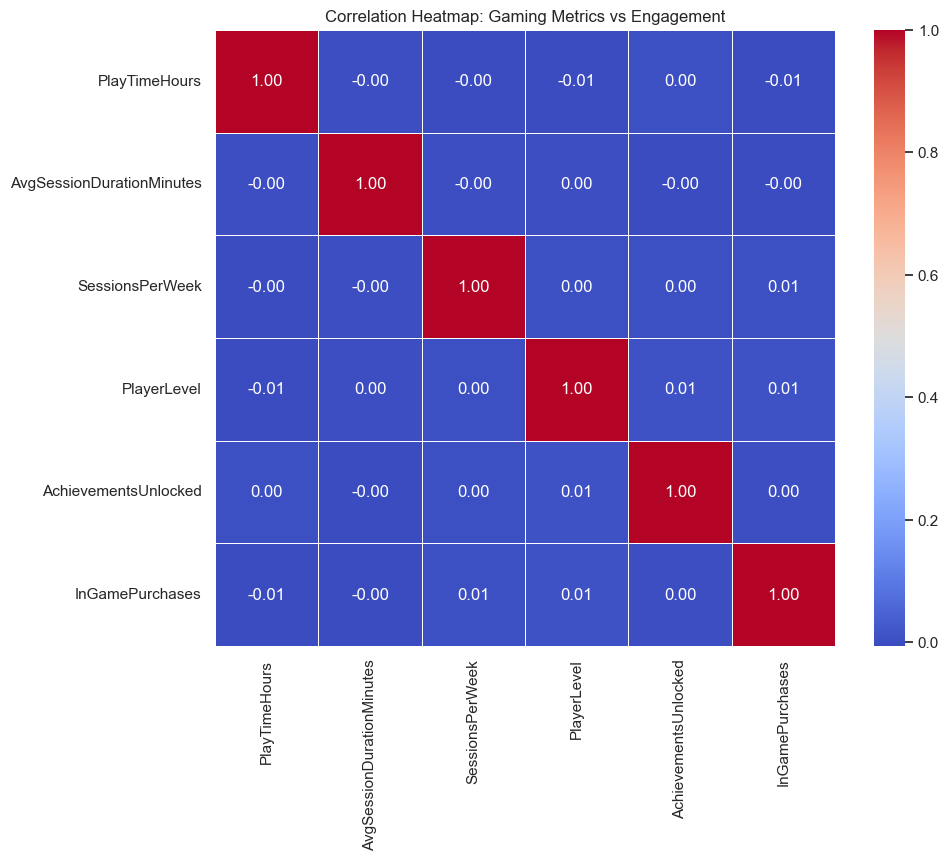

In [59]:
df.columns = df.columns.str.strip()
print("当前所有的列名有：", df.columns.tolist())

# 2. 安全检查：只有当 EngagementLevel 还是文字时才进行转换
df_corr = df.copy()

if 'EngagementLevel' in df_corr.columns:
    # 检查这一列是不是已经是数字了（如果是数字就不用 map 了）
    if df_corr['EngagementLevel'].dtype == 'object':
        mapping = {'Low': 0, 'Medium': 1, 'High': 2}
        df_corr['EngagementLevel_Num'] = df_corr['EngagementLevel'].map(mapping)
    else:
        # 如果已经是数字，直接复制一份
        df_corr['EngagementLevel_Num'] = df_corr['EngagementLevel']
else:
    print("错误：找不到 EngagementLevel 列，请检查上面的 print 结果！")

# 3. 选择列（确保这些列名在你的数据里都存在）
# 注意：这里我用了 EngagementLevel_Num
cols = ['EngagementLevel_Num', 'PlayTimeHours', 'AvgSessionDurationMinutes', 
        'SessionsPerWeek', 'PlayerLevel', 'AchievementsUnlocked', 'InGamePurchases']

# 过滤掉数据中实际不存在的列，防止再次报错
existing_cols = [c for c in cols if c in df_corr.columns]

# 4. 计算相关系数矩阵并画图
correlation_matrix = df_corr[existing_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Gaming Metrics vs Engagement')
plt.show()

In [64]:
from sklearn.preprocessing import LabelEncoder

# 1. 清理列名（防止有看不见的空格导致 KeyError）
data.columns = data.columns.str.strip()

# 2. 定义我们要留下的“核心特征” (这里面没有 PlayerID，等于把它删了)
selected_columns = [
    'Age', 'Gender', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 
    'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 
    'AchievementsUnlocked', 'Location', 'EngagementLevel'
]

# 3. 使用 .loc 提取数据（直接用你定义的 data 变量）
# 如果你的变量名是 data，就不要用 df
df_final = data.loc[:, selected_columns].copy()

# 4. 转换数据类型 (这步是必须的，否则模型跑不动)
df_final['EngagementLevel'] = df_final['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_final['Gender'] = LabelEncoder().fit_transform(df_final['Gender'])
df_final = pd.get_dummies(df_final, columns=['Location', 'GameGenre'])

df_final.head(10)

,Age,Gender,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,6,108,79,25,1,False,False,True,False,False,False,False,False,True
1,29,0,5.525961,0,5,144,11,10,1,False,False,False,True,False,False,False,False,True
2,22,0,8.223755,0,16,142,35,41,2,False,False,False,True,False,False,False,True,False
3,35,1,5.265351,1,9,85,57,47,1,False,False,False,True,True,False,False,False,False
4,33,1,15.531945,0,2,131,95,37,1,False,True,False,False,True,False,False,False,False
5,37,1,20.561855,0,2,81,74,22,0,False,True,False,False,False,True,False,False,False
6,25,1,9.752716,0,1,50,13,2,0,False,False,False,True,True,False,False,False,False
7,25,0,4.401729,0,10,48,27,23,1,True,False,False,False,False,True,False,False,False
8,38,0,18.152733,0,5,101,23,41,1,False,True,False,False,False,False,True,False,False
9,38,0,23.942772,0,13,95,99,36,2,False,False,True,False,False,False,False,True,False


In [65]:


# 1. 使用测试集进行预测
y_pred = rf_model.predict(X_test)

# 2. 生成报告并转为 DataFrame 格式
report_dict = classification_report(y_test, y_pred, output_dict=True, target_names=['Low', 'Medium', 'High'])
report_df = pd.DataFrame(report_dict).transpose()

# 3. 整理表格格式 (保留 2 位小数，看起来更整齐)
report_df = report_df.round(2)
print("--- Model Prediction Performance Evaluation Table ---")
print(report_df)

--- Model Prediction Performance Evaluation Table ---
              precision  recall  f1-score  support
Low                0.90    0.87      0.88  2035.00
Medium             0.86    0.84      0.85  2093.00
High               0.89    0.91      0.90  3879.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.88    0.88      0.88  8007.00
weighted avg       0.88    0.88      0.88  8007.00


In [70]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_summary = feature_importance_df.head(10).round(3)

print("--- Feature Importance ---")
print(feature_importance_summary)

--- 关键影响因素排行榜 (Feature Importance) ---
                     Feature  Importance
0            SessionsPerWeek       0.489
1  AvgSessionDurationMinutes       0.391
2       AchievementsUnlocked       0.112
3           GameGenre_Sports       0.002
4         GameGenre_Strategy       0.002
5              GameGenre_RPG       0.002
6           GameGenre_Action       0.001
7       GameGenre_Simulation       0.001


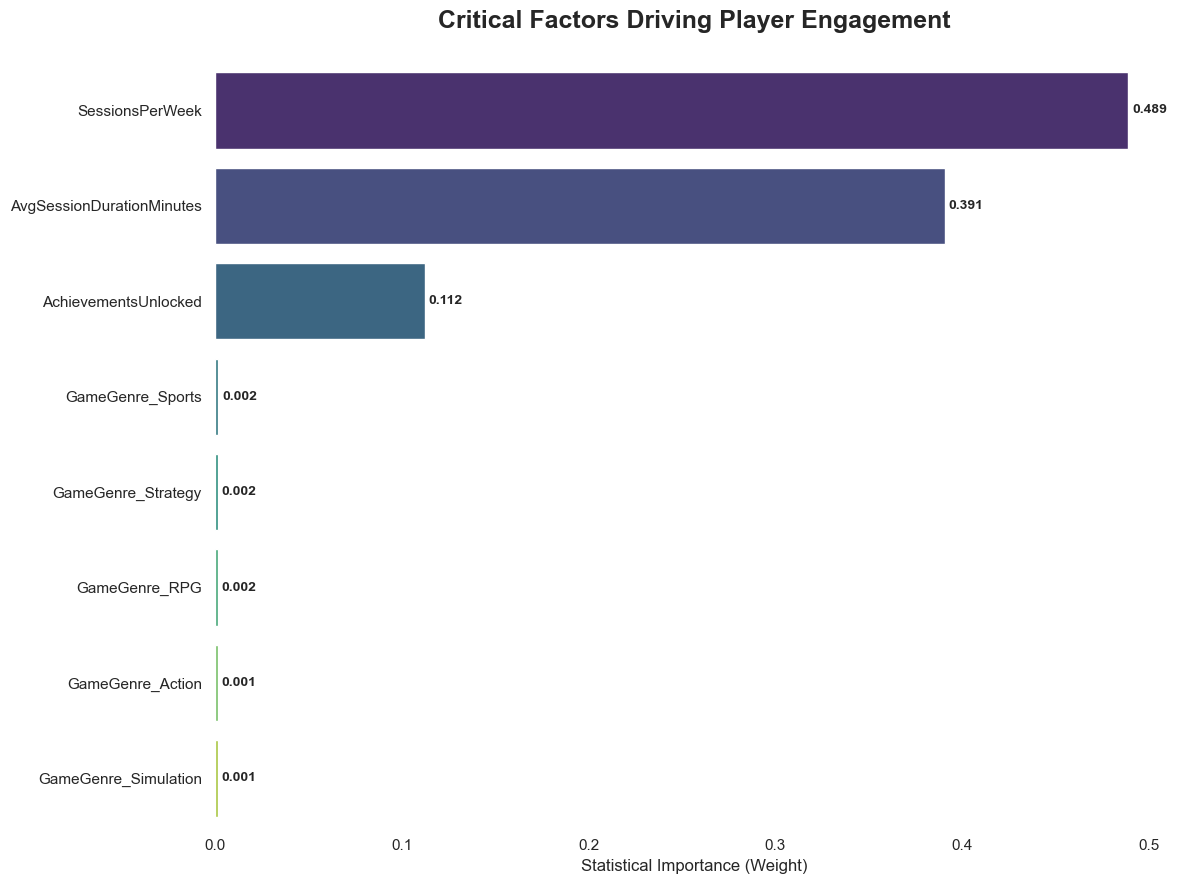

In [81]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 2. 绘图美化 ---
plt.figure(figsize=(12, 9)) # 稍微调高一点，防止字挤在一起
sns.set_style("white") 

# 使用 viridis 渐变色，看起来非常高端
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- 3. 添加精确数值标签 (灵魂所在) ---
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002,  # 稍微往右偏移一点
            p.get_y() + p.get_height()/2, 
            f'{width:.3f}', 
            va='center', fontsize=10, fontweight='bold')

# --- 4. 标题与细节优化 ---
plt.title('Critical Factors Driving Player Engagement', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Statistical Importance (Weight)', fontsize=12)
plt.ylabel('') # 隐藏纵轴标题，让图面更干净
sns.despine(left=True, bottom=True) # 去掉外框

plt.tight_layout()
plt.show()

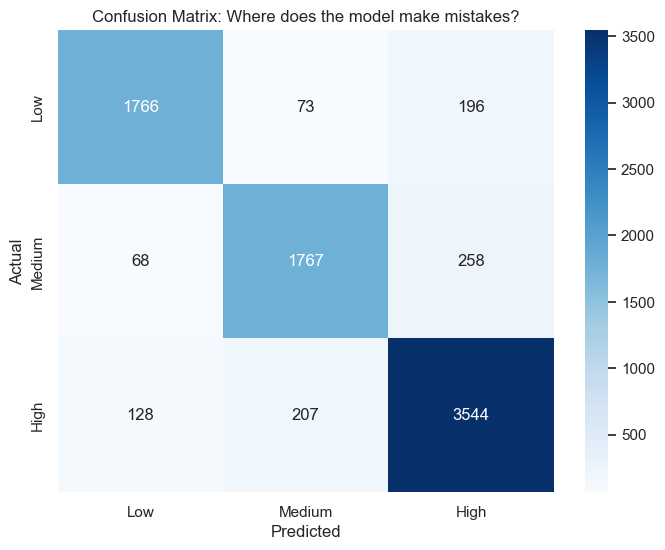

In [78]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where does the model make mistakes?')
plt.show()

In [67]:
probabilities = rf_model.predict_proba(X_test[:5])
prob_df = pd.DataFrame(probabilities, columns=['Low_Prob', 'Medium_Prob', 'High_Prob'])
print(prob_df)

   Low_Prob  Medium_Prob  High_Prob
0      0.00       0.0500     0.9500
1      0.00       0.0000     1.0000
2      0.01       0.2100     0.7800
3      0.00       0.0605     0.9395
4      0.33       0.0200     0.6500


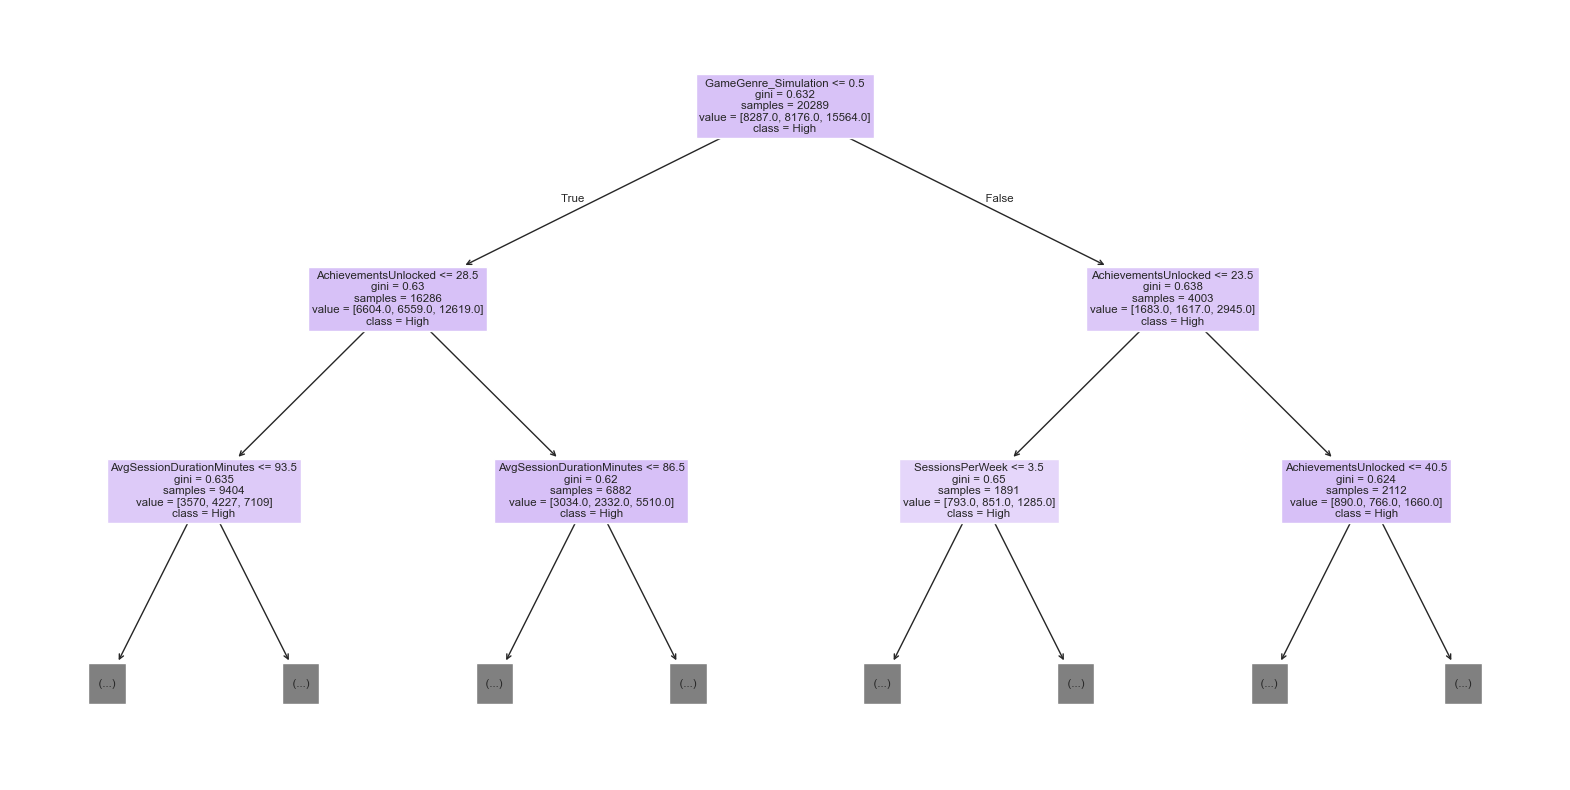

In [68]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(rf_model.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Low', 'Medium', 'High'], 
          filled=True, 
          max_depth=2) # 只看前两层，不然太密了看不清
plt.show()